<a href="https://colab.research.google.com/github/hosseinrezaie0/CI---T.A---Dr.Soltani/blob/main/CI_NN_MLP_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings as wr

wr.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Titanic.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [ ]:
# Drop the Cabin column - Too many missing values
df.drop('Cabin', axis=1, inplace=True)

# Drop the Ticket column - Not useful
df.drop('Ticket', axis=1, inplace=True)

# Drop the Name column - Not useful
df.drop('Name', axis=1, inplace=True)

# Drop the PassengerId column - Not useful
df.drop('PassengerId', axis=1, inplace=True)

In [ ]:
# Replace null value in age column with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Replace null value in Fare column with mean
df['Fare'].fillna(df['Fare'].mean(), inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.5,0,0,7.8292,Q
1,1,3,female,47.0,1,0,7.0000,S
2,0,2,male,62.0,0,0,9.6875,Q
3,0,3,male,27.0,0,0,8.6625,S
4,1,3,female,22.0,1,1,12.2875,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Pclass    418 non-null    int64  
 2   Sex       418 non-null    object 
 3   Age       418 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Fare      418 non-null    float64
 7   Embarked  418 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 26.3+ KB


In [ ]:
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Pclass    418 non-null    int64  
 2   Sex       418 non-null    int64  
 3   Age       418 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Fare      418 non-null    float64
 7   Embarked  418 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 26.3 KB


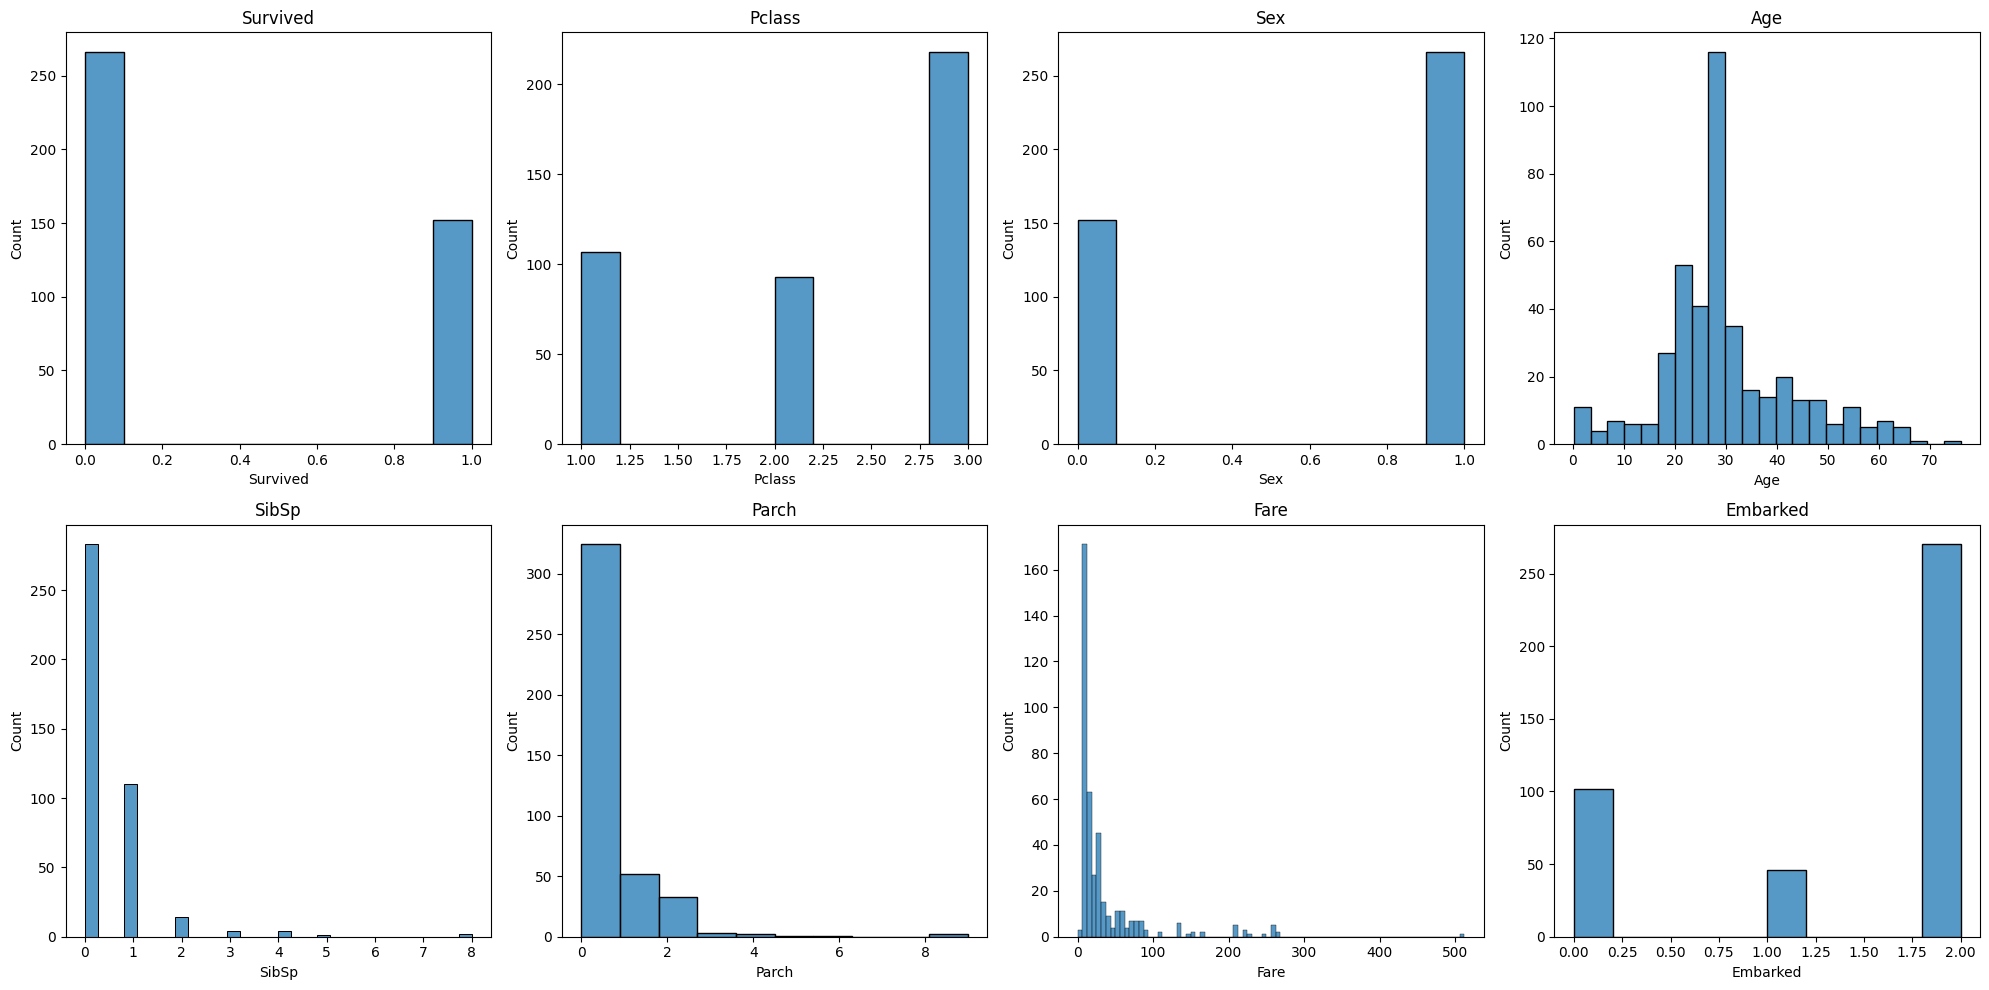

In [ ]:
fig, axes = plt.subplots(2,4, figsize=(20,10))
axes = axes.flatten()
for i, col_name in enumerate(df.columns):

  sns.histplot(df[col_name], ax=axes[i])
  axes[i].set_title(col_name)

plt.tight_layout()
plt.show()

In [ ]:
# Normalize Fare and Age
scaler = StandardScaler()
df['Fare'] = scaler.fit_transform(df['Fare'].values.reshape(-1,1))
df['Age'] = scaler.fit_transform(df['Age'].values.reshape(-1,1))

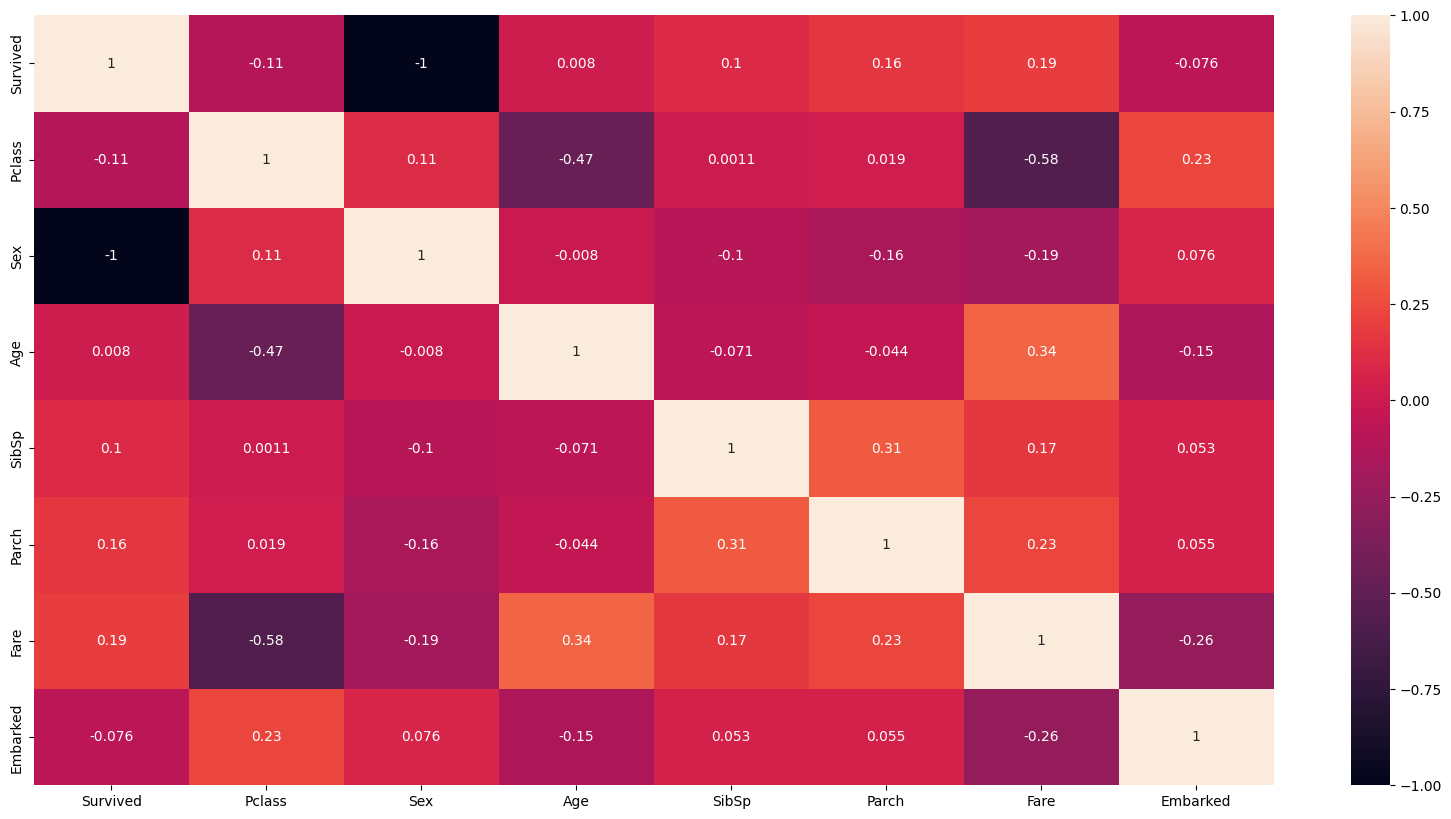

In [ ]:
fig = plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((334, 7), (84, 7), (334,), (84,))

In [ ]:
MLP = Sequential(
    [
        Dense(12, activation='relu', input_shape=(7,)),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

MLP.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = MLP.fit(x_train, y_train, epochs=10, batch_size=8, validation_split=0.2)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4110 - loss: 0.7434 - val_accuracy: 0.5075 - val_loss: 0.6999
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6159 - loss: 0.6806 - val_accuracy: 0.6716 - val_loss: 0.6552
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6794 - loss: 0.6282 - val_accuracy: 0.7313 - val_loss: 0.6234
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7098 - loss: 0.6041 - val_accuracy: 0.7463 - val_loss: 0.5903
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6909 - loss: 0.5613 - val_accuracy: 0.7761 - val_loss: 0.5531
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6993 - loss: 0.5306 - val_accuracy: 0.7761 - val_loss: 0.5041
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8209 - loss: 0.4590 - val_accuracy: 0.8209 - val_loss: 0.4475
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8542 - loss: 0.4144 - val_accuracy: 0.8657 - val_loss:

In [ ]:
train_loss = history.history['loss']
train_acc = history.history['accuracy']
val_loss = history.history['val_loss']
val_acc = history.history['val_accuracy']

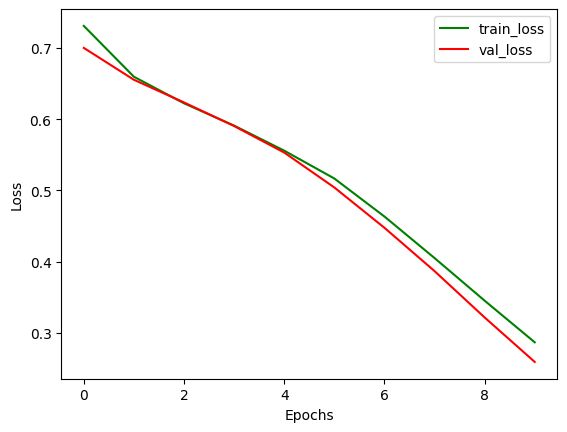

In [ ]:
plt.plot(train_loss, label='train_loss', color='green')
plt.plot(val_loss, label='val_loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
y_pred = MLP.predict(x_test)
y_pred = (y_pred > 0.5)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [ ]:
test_loss, test_acc = MLP.evaluate(x_test, y_test)
print('Test Loss: ', test_loss)
print('Test Accuracy: ', test_acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9823 - loss: 0.2696
Test Loss:  0.26544350385665894
Test Accuracy:  0.988095223903656


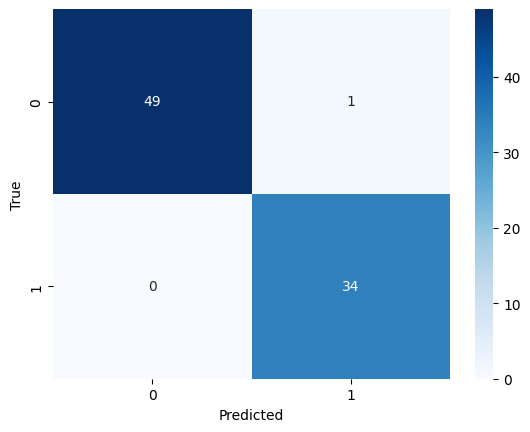

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
